In [ ]:
# implementing PINN using pytorch for solving  diffusion equation
import torch
import torch.nn as nn

class Pinn_d(nn.Module):
  def __init__(self):
    super(Pinn_d,self).__init__()
    self.net=nn.Sequential(
        nn.Linear(2,32),
        nn.Tanh(),
        nn.Linear(32,32),
        nn.Tanh(),
        nn.Linear(32,1  )
    )
  def forward(self,x,t):
    inputs= torch.cat([x,t],dim=1)
    return self.net(inputs)
  def physics_loss(self,x,t):
    D=1.0
    t=t.clone().requires_grad_(True)
    x=x.clone().requires_grad_(True)
    u_pred=self(x,t)
    u_x=torch.autograd.grad(u_pred,x,grad_outputs=torch.ones_like(u_pred),create_graph=True)[0]
    u_t=torch.autograd.grad(u_pred,t,grad_outputs=torch.ones_like(u_pred),create_graph=True)[0]
    u_xx=torch.autograd.grad(u_x,x,grad_outputs=torch.ones_like(u_x),create_graph=True)[0]

    res=u_t-D*u_xx
    return torch.mean( res**2)

  def IC_loss(self,x):
    sigma=1
    x0=0
    t_zeros=torch.zeros_like(x)
    u_pred=self(x,t_zeros)
    #Gaussian boundary condition
    f=(torch.exp(-(x-x0)**2/(2*sigma**2)))/(sigma*(2*torch.tensor(torch.pi))**(0.5))
    return torch.mean((u_pred-f)**2)



  def train_model(self,epochs,lr,x_p,t_p,x_b,x_b2):
    optimizer=torch.optim.Adam(self.parameters(),lr)
    prv_loss=0
    loss_history=[]

    for epoch in range(epochs):
      optimizer.zero_grad()
      x_b_rep=x_b.expand(t_p.shape[0],1).clone().requires_grad_(True)
      x_b2_rep=x_b2.expand(t_p.shape[0],1).clone().requires_grad_(True)

      u_b=self(x_b_rep,t_p)
      u_b2=self(x_b2_rep,t_p)
      bc_loss=torch.autograd.grad(u_b,x_b_rep,grad_outputs=torch.ones_like(u_b),create_graph=True)[0]
      boundary_loss=torch.mean(bc_loss**2)
      b_loss2= torch.autograd.grad(u_b2,x_b2_rep,grad_outputs=torch.ones_like(u_b2),create_graph=True)[0]
      boundary_loss2=torch.mean(b_loss2**2)

      Loss=(2*self.physics_loss(x_p,t_p)+5*boundary_loss+5*boundary_loss2+2*self.IC_loss(x_p))

      Loss.backward()
      optimizer.step()
      loss_history.append(Loss.item())

      curr_loss=Loss.item()
      if epoch % 100 == 0:
        if epoch>0:
          diff_loss=curr_loss-prv_loss
          print(f"Epoch {epoch:4d}:Loss {Loss.item():.6f}|differnce in loss {diff_loss:.6f}")
        else:
          print(f"Epoch {epoch:4d}: Loss {Loss.item():.6f}| no previous loss")
      prv_loss=curr_loss
    return loss_history

Epoch    0: Loss 0.340315| no previous loss
Epoch  100:Loss 0.002414|differnce in loss -0.000031
Epoch  200:Loss 0.001020|differnce in loss -0.000006
Epoch  300:Loss 0.000668|differnce in loss -0.000002
Epoch  400:Loss 0.000526|differnce in loss -0.000001
Epoch  500:Loss 0.000438|differnce in loss -0.000001
Epoch  600:Loss 0.000373|differnce in loss -0.000001
Epoch  700:Loss 0.000322|differnce in loss -0.000000
Epoch  800:Loss 0.000283|differnce in loss -0.000000
Epoch  900:Loss 0.000250|differnce in loss -0.000000
Epoch 1000:Loss 0.000221|differnce in loss -0.000000
Epoch 1100:Loss 0.000197|differnce in loss -0.000000
Epoch 1200:Loss 0.000176|differnce in loss -0.000000
Epoch 1300:Loss 0.000158|differnce in loss -0.000000
Epoch 1400:Loss 0.000142|differnce in loss -0.000000
Epoch 1500:Loss 0.000128|differnce in loss -0.000000
Epoch 1600:Loss 0.000115|differnce in loss -0.000000
Epoch 1700:Loss 0.000105|differnce in loss -0.000000
Epoch 1800:Loss 0.000096|differnce in loss -0.000000
Ep

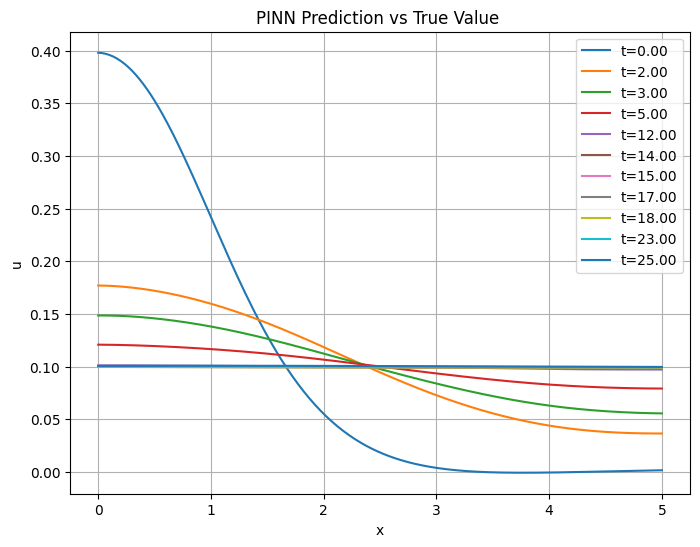

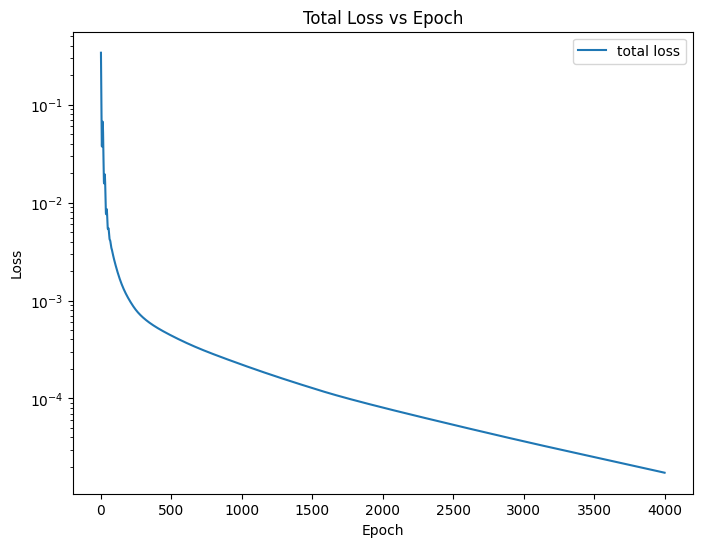

In [ ]:

#plotting
import numpy as np
import matplotlib.pyplot as plt
#  Define training points


x_pnp=np.random.rand(25000,1)*5
t_pnp=np.random.rand(25000,1)*25
x_bnp = np.array([[0.0]])
#y_bnp = np.array([[-1.0]])
x_b2np=np.array([[5.0]])
#y_b2np=np.array([[-1.0]])
model=Pinn_d()
x_p=torch.tensor(x_pnp,dtype=torch.float32)
t_p=torch.tensor(t_pnp,dtype=torch.float32)
x_b=torch.tensor(x_bnp,dtype=torch.float32)
#y_b=torch.tensor(y_bnp,dtype=torch.float32)
x_b2=torch.tensor(x_b2np,dtype=torch.float32)
#y_b2=torch.tensor(y_b2np,dtype=torch.float32)

loss_history=model.train_model(4000,0.001,x_p,t_p, x_b,x_b2)
x_plot_np=np.linspace(0,5,300).reshape(-1,1)
t_vals_np=np.linspace(0,25,300).reshape(-1,1)
t_plot=torch.tensor(t_vals_np,dtype=torch.float32)
x_plot=torch.tensor(x_plot_np,dtype=torch.float32)
snapshot=[0,2,3,5,12,14,15,17,18,23,25]
plt.figure(figsize=(8, 6))

for t_val in snapshot:
  t_=torch.full_like(x_plot,t_val)
  with torch.no_grad():
    u_vals=model(x_plot,t_plot).numpy()
    u_pred=model(x_plot,t_).numpy()
  plt.plot(x_plot_np, u_pred, label=f't={t_val:.2f}')
  plt.xlabel("x")
  plt.ylabel("u")
  plt.grid(True)
  plt.title(r"PINN Prediction vs True Value ")
  plt.legend()
plt.figure(figsize=(8, 6))
plt.plot(loss_history, label='total loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Total Loss vs Epoch')
plt.legend()
plt.show()
np.savez('diffussion datas.npz',x=x_plot_np.flatten().reshape(-1,1),t=t_vals_np.flatten().reshape(-1,1),u=u_vals)

In [ ]:
# implementing PINN using pytorch for solving  diffusion equation
import torch
import torch.nn as nn

class Pinn_inv_d(nn.Module):
  def __init__(self):
    super( Pinn_inv_d,self).__init__()
    self.net=nn.Sequential(
        nn.Linear(2,32),
        nn.Tanh(),
        nn.Linear(32,32),
        nn.Tanh(),
        nn.Linear(32,1)
    )
    self.D=nn.Parameter(torch.tensor(0.6))
  def forward(self,x,t):
    inputs= torch.cat([x,t],dim=1)
    return self.net(inputs)
  def physics_loss(self,x,t):
    D=1.0
    t=t.clone().requires_grad_(True)
    x=x.clone().requires_grad_(True)
    u_pred=self(x,t)
    u_x=torch.autograd.grad(u_pred,x,grad_outputs=torch.ones_like(u_pred),create_graph=True)[0]
    u_t=torch.autograd.grad(u_pred,t,grad_outputs=torch.ones_like(u_pred),create_graph=True)[0]
    u_xx=torch.autograd.grad(u_x,x,grad_outputs=torch.ones_like(u_x),create_graph=True)[0]

    res=u_t-self.D*u_xx
    return torch.mean( res**2)

  def IC_loss(self,x):
    sigma=1
    x0=0
    t_zeros=torch.zeros_like(x)
    u_pred=self(x,t_zeros)
    #Gaussian boundary condition
    f=(torch.exp(-(x-x0)**2/(2*sigma**2)))/(sigma*(2*torch.tensor(torch.pi))**(0.5))
    return torch.mean((u_pred-f)**2)

  def data_loss(self,x,t,u):
    u_pred=self(x,t)
    return torch.mean((u_pred-u)**2)

  def train_model(self,epochs,lr,x_obs,t_obs,u_obs,x_b,x_b2):
    optimizer=torch.optim.Adam(self.parameters(),lr)
    prv_loss=0
    loss_history=[]
    D_vals=[]

    for epoch in range(epochs):
      optimizer.zero_grad()

      x_b_rep=x_b.expand(t_p.shape[0],1).clone().requires_grad_(True)
      x_b2_rep=x_b2.expand(t_p.shape[0],1).clone().requires_grad_(True)

      u_b=self(x_b_rep,t_p)
      u_b2=self(x_b2_rep,t_p)
      bc_loss=torch.autograd.grad(u_b,x_b_rep,grad_outputs=torch.ones_like(u_b),create_graph=True)[0]
      boundary_loss=torch.mean(bc_loss**2)
      b_loss2= torch.autograd.grad(u_b2,x_b2_rep,grad_outputs=torch.ones_like(u_b2),create_graph=True)[0]
      boundary_loss2=torch.mean(b_loss2**2)

      Loss=(8*self.physics_loss(x_p,t_p)+5*boundary_loss+5*boundary_loss2+3*self.IC_loss(x_p)+7*self.data_loss(x_obs,t_obs,u_obs))

      Loss.backward()
      optimizer.step()
      loss_history.append(Loss.item())
      D_vals.append(self.D.item())

      curr_loss=Loss.item()
      if epoch % 100 == 0:
        if epoch>0:
          diff_loss=curr_loss-prv_loss
          print(f"Epoch {epoch:4d}:Loss {Loss.item():.6f}|differnce in loss {diff_loss:.6f}|D{self.D.item():.4f}")
        else:
          print(f"Epoch {epoch:4d}: Loss {Loss.item():.6f}| no previous loss")
      prv_loss=curr_loss
    return loss_history,D_vals

Epoch    0: Loss 1.972011| no previous loss
Epoch  100:Loss 0.010272|differnce in loss -0.000078|D0.5522
Epoch  200:Loss 0.005048|differnce in loss -0.000030|D0.5646
Epoch  300:Loss 0.003035|differnce in loss -0.000014|D0.5588
Epoch  400:Loss 0.001953|differnce in loss -0.000007|D0.5603
Epoch  500:Loss 0.001424|differnce in loss -0.000004|D0.5598
Epoch  600:Loss 0.001179|differnce in loss -0.000002|D0.5607
Epoch  700:Loss 0.001033|differnce in loss -0.000001|D0.5699
Epoch  800:Loss 0.000922|differnce in loss -0.000001|D0.5829
Epoch  900:Loss 0.000828|differnce in loss -0.000001|D0.5980
Epoch 1000:Loss 0.000741|differnce in loss -0.000001|D0.6145
Epoch 1100:Loss 0.000660|differnce in loss -0.000001|D0.6319
Epoch 1200:Loss 0.000585|differnce in loss -0.000001|D0.6495
Epoch 1300:Loss 0.000516|differnce in loss -0.000001|D0.6656
Epoch 1400:Loss 0.000456|differnce in loss -0.000001|D0.6780
Epoch 1500:Loss 0.000409|differnce in loss -0.000000|D0.6850
Epoch 1600:Loss 0.000373|differnce in los

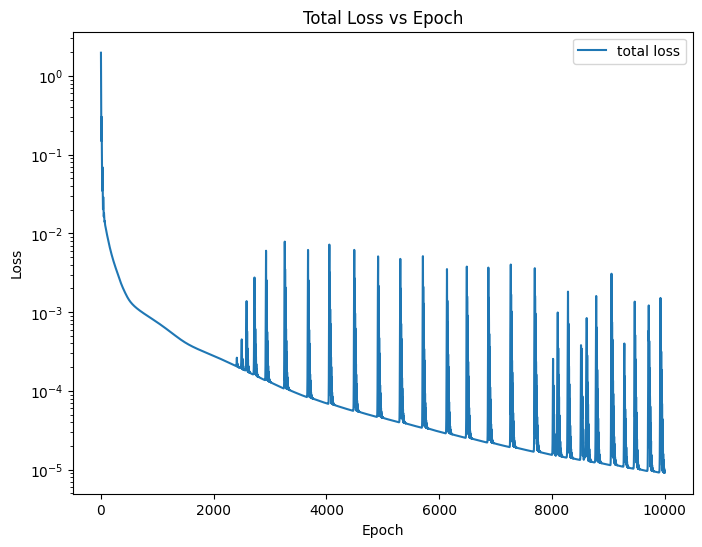

In [ ]:
data=np.load('diffussion datas.npz')
x_=data['x']
t_=data['t']
u_=data['u']
x_obs=torch.tensor(x_,dtype=torch.float32)
t_obs=torch.tensor(t_,dtype=torch.float32)
u_obs=torch.tensor(u_,dtype=torch.float32)
x_b=torch.tensor(x_bnp,dtype=torch.float32)
#y_b=torch.tensor(y_bnp,dtype=torch.float32)
x_b2=torch.tensor(x_b2np,dtype=torch.float32)
#y_b2=torch.tensor(y_b2np,dtype=torch.float32)
x_bnp = np.array([[0.0]])
#y_bnp = np.array([[-1.0]])
x_b2np=np.array([[5.0]])
#y_b2np=np.array([[-1.0]])
model=Pinn_inv_d()
loss_history,D_vals=model.train_model(10001,0.003,x_obs,t_obs,u_obs, x_b,x_b2)

print(D_vals)
plt.figure(figsize=(8, 6))
plt.plot(loss_history, label='total loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Total Loss vs Epoch')
plt.legend()
plt.show()

In [1]:
import numpy as np

def f(x):
  sigma=1
  x0=2.5
  return (np.exp(-(x-x0)**2/(2*sigma**2)))/(sigma*(2*(np.pi))**(0.5))

def finite_diff(x_p,nx,L,save_every=5000):
  dx=L/(nx-1)
  D=1
  t=20
  dt=0.4*(dx**2)/D
  nt=int(t/dt)
  u_now=f(x_p)
  u_list=[u_now.copy()]          # store only some time steps
  t_list=[0.0]
  for l in range(nt-1):
    u_new=u_now.copy()
    u_new[1:-1]=u_now[1:-1]+((D*dt)/dx**2)*(u_now[:-2]-2*u_now[1:-1]+u_now[2:])
    u_new[0]=u_new[1]
    u_new[-1]=u_new[-2]
    u_now=u_new
    if (l+1) % save_every == 0:
      u_list.append(u_now.copy())
      t_list.append((l+1)*dt)
  return np.array(u_list).T, np.array(t_list), nt, dt   # u shape: (nx, n_saved)

L=5
nx=600
x_p=np.linspace(0, L, nx)
u_exp, t_saved, nt_exp, dt_exp = finite_diff(x_p, nx, L)

# make (x,t) grid and flatten to (N,1), same format your inverse PINN already expects
X,T=np.meshgrid(x_p,t_saved,indexing='ij')
x_all=X.reshape(-1,1)
t_all=T.reshape(-1,1)
u_all=u_exp.reshape(-1,1)

# take random points as "observed" data (full grid is too big and slow for PINN)
idx=np.random.choice(len(x_all),5000,replace=False)
np.savez('diffussion datas.npz',x=x_all[idx],t=t_all[idx],u=u_all[idx])

Epoch    0: Loss 0.290246| no previous loss
Epoch  100:Loss 0.022092|differnce in loss -0.000175|D0.3978
Epoch  200:Loss 0.011283|differnce in loss -0.000068|D0.4990
Epoch  300:Loss 0.006199|differnce in loss -0.000036|D0.6511
Epoch  400:Loss 0.003449|differnce in loss -0.000021|D0.7348
Epoch  500:Loss 0.001924|differnce in loss -0.000254|D0.7712
Epoch  600:Loss 0.001191|differnce in loss -0.000005|D0.7822
Epoch  700:Loss 0.000846|differnce in loss -0.000002|D0.7877
Epoch  800:Loss 0.001185|differnce in loss -0.000402|D0.7902
Epoch  900:Loss 0.000528|differnce in loss -0.000001|D0.7940
Epoch 1000:Loss 0.000934|differnce in loss -0.000427|D0.7962
Epoch 1100:Loss 0.000390|differnce in loss -0.000001|D0.8037
Epoch 1200:Loss 0.000340|differnce in loss -0.000000|D0.8124
Epoch 1300:Loss 0.000333|differnce in loss 0.000000|D0.8181
Epoch 1400:Loss 0.000279|differnce in loss -0.000000|D0.8264
Epoch 1500:Loss 0.000251|differnce in loss -0.000000|D0.8359
Epoch 1600:Loss 0.000765|differnce in loss

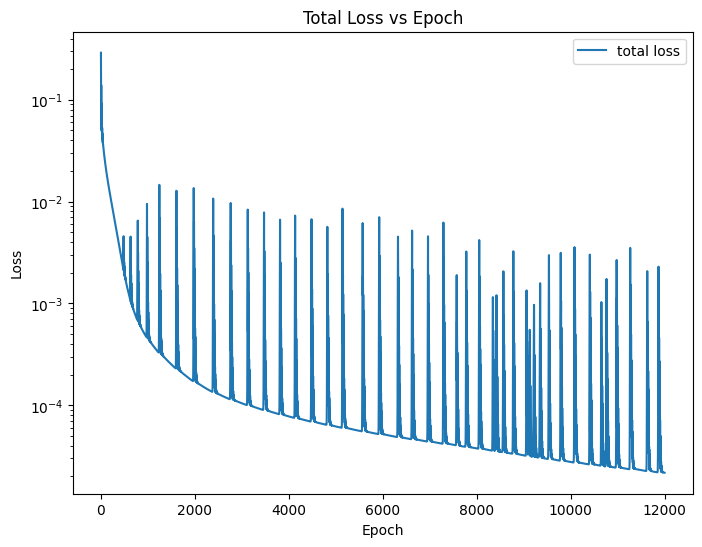

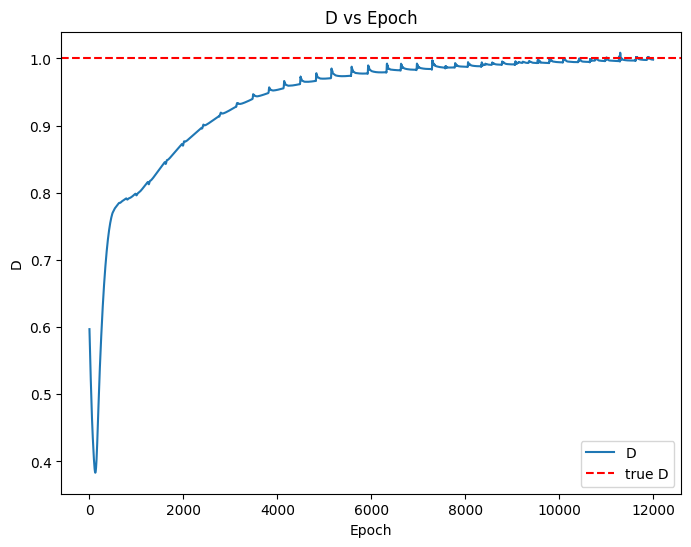

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

class Pinn_inv_d(nn.Module):
  def __init__(self):
    super( Pinn_inv_d,self).__init__()
    self.net=nn.Sequential(
        nn.Linear(2,32),
        nn.Tanh(),
        nn.Linear(32,32),
        nn.Tanh(),
        nn.Linear(32,1)
    )
    self.D=nn.Parameter(torch.tensor(0.6))
  def forward(self,x,t):
    inputs= torch.cat([x,t],dim=1)
    return self.net(inputs)
  def physics_loss(self,x,t):
    D=1.0
    t=t.clone().requires_grad_(True)
    x=x.clone().requires_grad_(True)
    u_pred=self(x,t)
    u_x=torch.autograd.grad(u_pred,x,grad_outputs=torch.ones_like(u_pred),create_graph=True)[0]
    u_t=torch.autograd.grad(u_pred,t,grad_outputs=torch.ones_like(u_pred),create_graph=True)[0]
    u_xx=torch.autograd.grad(u_x,x,grad_outputs=torch.ones_like(u_x),create_graph=True)[0]

    res=u_t-self.D*u_xx
    return torch.mean( res**2)

  def IC_loss(self,x):
    sigma=1
    x0=2.5                                   # CHANGED (was 0), matches FD data
    t_zeros=torch.zeros_like(x)
    u_pred=self(x,t_zeros)
    #Gaussian initial condition
    f=(torch.exp(-(x-x0)**2/(2*sigma**2)))/(sigma*(2*torch.tensor(torch.pi))**(0.5))
    return torch.mean((u_pred-f)**2)

  def data_loss(self,x,t,u):
    u_pred=self(x,t)
    return torch.mean((u_pred-u)**2)

  def train_model(self,epochs,lr,x_obs,t_obs,u_obs,x_b,x_b2):
    optimizer=torch.optim.Adam(self.parameters(),lr)
    prv_loss=0
    loss_history=[]
    D_vals=[]

    for epoch in range(epochs):
      optimizer.zero_grad()

      x_b_rep=x_b.expand(t_p.shape[0],1).clone().requires_grad_(True)
      x_b2_rep=x_b2.expand(t_p.shape[0],1).clone().requires_grad_(True)

      u_b=self(x_b_rep,t_p)
      u_b2=self(x_b2_rep,t_p)
      bc_loss=torch.autograd.grad(u_b,x_b_rep,grad_outputs=torch.ones_like(u_b),create_graph=True)[0]
      boundary_loss=torch.mean(bc_loss**2)
      b_loss2= torch.autograd.grad(u_b2,x_b2_rep,grad_outputs=torch.ones_like(u_b2),create_graph=True)[0]
      boundary_loss2=torch.mean(b_loss2**2)

      Loss=(8*self.physics_loss(x_p,t_p)+5*boundary_loss+5*boundary_loss2+3*self.IC_loss(x_p)+7*self.data_loss(x_obs,t_obs,u_obs))

      Loss.backward()
      optimizer.step()
      loss_history.append(Loss.item())
      D_vals.append(self.D.item())

      curr_loss=Loss.item()
      if epoch % 100 == 0:
        if epoch>0:
          diff_loss=curr_loss-prv_loss
          print(f"Epoch {epoch:4d}:Loss {Loss.item():.6f}|differnce in loss {diff_loss:.6f}|D{self.D.item():.4f}")
        else:
          print(f"Epoch {epoch:4d}: Loss {Loss.item():.6f}| no previous loss")
      prv_loss=curr_loss
    return loss_history,D_vals

# ---------- load FD data ----------
data=np.load('diffussion datas.npz')
x_=data['x']
t_=data['t']
u_=data['u']
x_obs=torch.tensor(x_,dtype=torch.float32)
t_obs=torch.tensor(t_,dtype=torch.float32)
u_obs=torch.tensor(u_,dtype=torch.float32)

# CHANGED: these two lines moved ABOVE where they are used
x_bnp = np.array([[0.0]])
x_b2np=np.array([[5.0]])
x_b=torch.tensor(x_bnp,dtype=torch.float32)
x_b2=torch.tensor(x_b2np,dtype=torch.float32)

# CHANGED: collocation points defined here (train_model uses them as globals)
x_p=torch.tensor(np.random.rand(25000,1)*5,dtype=torch.float32)
t_p=torch.tensor(np.random.rand(25000,1)*20,dtype=torch.float32)   # 20 instead of 25

model=Pinn_inv_d()
loss_history,D_vals=model.train_model(12001,0.003,x_obs,t_obs,u_obs, x_b,x_b2)

print("Recovered D:",D_vals[-1],"(true D = 1.0)")

plt.figure(figsize=(8, 6))
plt.plot(loss_history, label='total loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Total Loss vs Epoch')
plt.legend()

plt.figure(figsize=(8, 6))
plt.plot(D_vals, label='D')
plt.axhline(1.0, color='r', linestyle='--', label='true D')
plt.xlabel('Epoch')
plt.ylabel('D')
plt.title('D vs Epoch')
plt.legend()
plt.show()